## 2. Configuration de l'environnement Python et du jeu de données

Nous allons commencer par importer toutes les bibliothèques nécessaires pour ce défi.

## 5. Visualiser la frontière de décision

Pour mieux comprendre comment nos modèles classifient les données, nous allons implémenter une fonction pour visualiser leurs frontières de décision. Cette fonction créera une grille de points, prédira la classe pour chaque point, puis tracera ces prédictions, ainsi que les données originales.

Frontière de décision pour le Modèle 1 (de base):
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


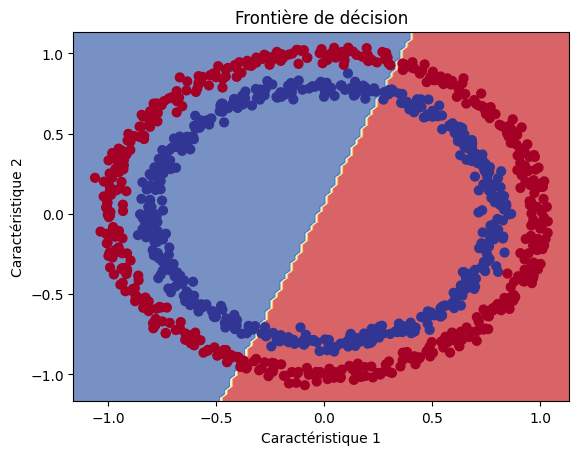

Frontière de décision pour le Modèle 2 (amélioré):
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


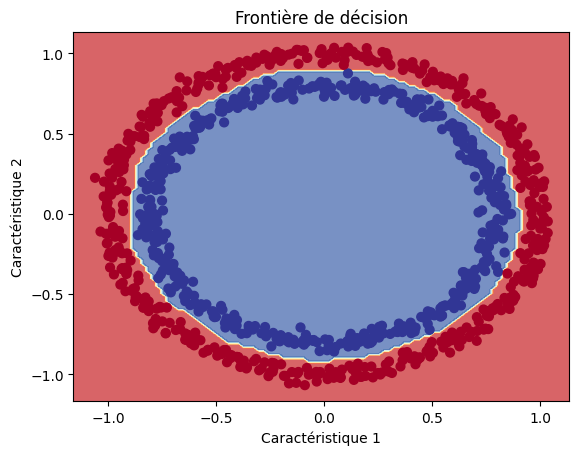

In [14]:
import numpy as np # Importation de numpy pour les opérations numériques.
import matplotlib.pyplot as plt # Importation de matplotlib pour le traçage.

def plot_decision_boundary(model, X, y):
    """
    Trace la frontière de décision créée par un modèle de classification.

    Args:
        model: Le modèle TensorFlow/Keras entraîné.
        X: Les caractéristiques d'entrée.
        y: Les vraies étiquettes.
    """
    # Définir les plages min et max pour X et Y pour créer une grille couvrant l'espace des données.
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Créer une grille de points uniformément espacés dans les plages définies.
    # xx et yy représentent les coordonnées de cette grille.
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Aplatir les coordonnées de la grille pour les passer au modèle pour la prédiction.
    x_in = np.c_[xx.ravel(), yy.ravel()]

    # Faire des prédictions sur tous les points de la grille.
    y_pred = model.predict(x_in)

    # Vérifier le type de sortie du modèle et le convertir si nécessaire.
    # Si la couche de sortie a plus d'un neurone (classification multi-classe),
    # on prend l'indice de la classe avec la probabilité la plus élevée.
    if model.output_shape[-1] > 1: # multi-classe
        y_pred = np.argmax(y_pred, axis=1)
    # Sinon (classification binaire), on arrondit les probabilités à 0 ou 1.
    else: # binaire
        y_pred = np.round(y_pred).flatten()

    # Remodeler les prédictions pour qu'elles correspondent à la forme de la grille (xx.shape).
    zz = y_pred.reshape(xx.shape)

    # Tracer la frontière de décision en utilisant plt.contourf.
    # contourf: Trace des contours remplis.
    # cmap=plt.cm.RdYlBu: Utilise une carte de couleurs pour visualiser les régions de décision.
    # alpha=0.7: Rend les régions semi-transparentes pour voir les points de données en dessous.
    plt.contourf(xx, yy, zz, cmap=plt.cm.RdYlBu, alpha=0.7)

    # Tracer les points de données originaux sur la frontière de décision.
    # c=y: Colore les points selon leurs vraies étiquettes.
    # s=40: Définit la taille des points.
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

    # Définir les limites des axes x et y pour correspondre à la grille.
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    # Ajouter un titre et des étiquettes aux axes.
    plt.title("Frontière de décision")
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")

    # Afficher le graphique.
    plt.show()

# Visualisation de la frontière de décision pour le modèle de base (model_1).
print("Frontière de décision pour le Modèle 1 (de base):")
plot_decision_boundary(model_1, X, y)

# Visualisation de la frontière de décision pour le modèle amélioré (model_2).
print("Frontière de décision pour le Modèle 2 (amélioré):")
plot_decision_boundary(model_2, X, y)

## 7. Séparer les données en ensembles d’entraînement et de test

Pour évaluer la capacité de généralisation de notre modèle, nous allons diviser notre jeu de données en un ensemble d'entraînement (80%) et un ensemble de test (20%). Le modèle sera entraîné sur l'ensemble d'entraînement et ses performances seront mesurées sur l'ensemble de test, qui n'aura jamais été vu auparavant par le modèle.

Forme de X_train: (800, 2)
Forme de y_train: (800,)
Forme de X_test: (200, 2)
Forme de y_test: (200,)

Perte du modèle sur l'ensemble de test: 0.0028
Précision du modèle sur l'ensemble de test: 1.0000


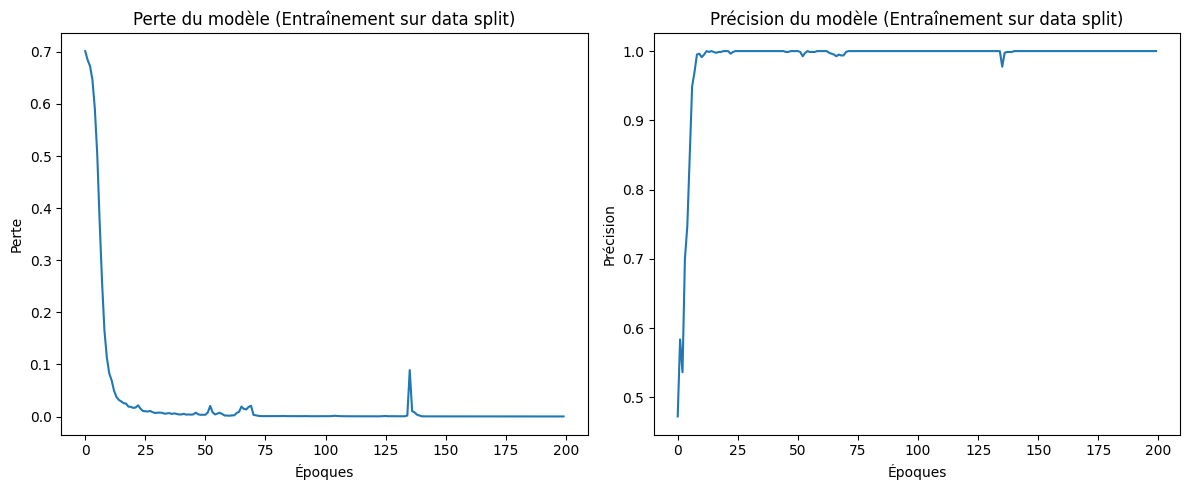

In [15]:
from sklearn.model_selection import train_test_split # Importation de la fonction pour diviser les données.

# Séparer les données en ensembles d'entraînement et de test.
# X: Caractéristiques, y: Étiquettes.
# test_size=0.2: 20% des données seront utilisées pour le test, 80% pour l'entraînement.
# random_state=42: Assure la reproductibilité de la division.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Afficher les formes des ensembles de données résultants pour vérifier la division.
print(f"Forme de X_train: {X_train.shape}")
print(f"Forme de y_train: {y_train.shape}")
print(f"Forme de X_test: {X_test.shape}")
print(f"Forme de y_test: {y_test.shape}")

# Recréer et entraîner le modèle amélioré (model_3) sur les données d'entraînement.
# Cela garantit que le modèle est entraîné uniquement sur les données d'entraînement,
# sans "voir" les données de test pendant l'apprentissage.
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Première couche cachée ReLU.
    tf.keras.layers.Dense(10, activation='relu'), # Deuxième couche cachée ReLU.
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie sigmoïde.
])

# Compiler le modèle model_3 de la même manière que model_2.
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# Entraîner model_3 sur les données d'entraînement.
history_3 = model_3.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer le modèle entraîné sur l'ensemble de test.
# Cela donne une mesure impartiale de la performance du modèle sur des données non vues.
loss_test, accuracy_test = model_3.evaluate(X_test, y_test, verbose=0)
print(f"\nPerte du modèle sur l'ensemble de test: {loss_test:.4f}")
print(f"Précision du modèle sur l'ensemble de test: {accuracy_test:.4f}")

# Visualisation de l'historique de l'entraînement (perte et précision) pour model_3.
plt.figure(figsize=(12, 5))

# Sous-graphique pour la perte d'entraînement.
plt.subplot(1, 2, 1)
plt.plot(history_3.history['loss'])
plt.title('Perte du modèle (Entraînement sur data split)')
plt.xlabel('Époques')
plt.ylabel('Perte')

# Sous-graphique pour la précision d'entraînement.
plt.subplot(1, 2, 2)
plt.plot(history_3.history['accuracy'])
plt.title('Précision du modèle (Entraînement sur data split)')
plt.xlabel('Époques')
plt.ylabel('Précision')

plt.tight_layout()
plt.show()

## 8. Évaluer et visualiser la performance finale du modèle

Après avoir entraîné notre modèle sur l'ensemble d'entraînement et l'avoir évalué sur l'ensemble de test, nous allons maintenant visualiser ses frontières de décision sur les deux ensembles. Cela nous aidera à confirmer que le modèle ne sur-apprend pas les données d'entraînement et qu'il généralise bien.

Frontière de décision pour le Modèle 3 (entraînement):
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


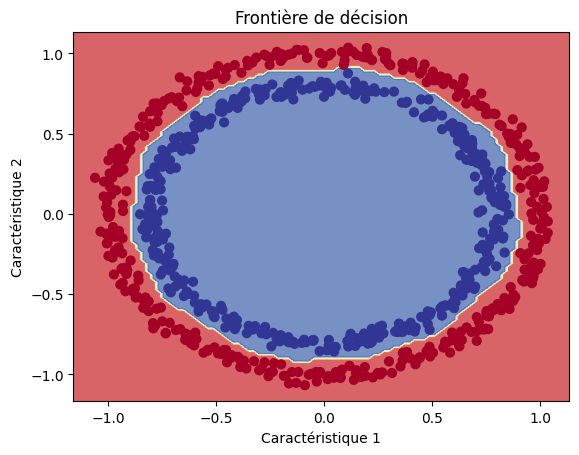

Frontière de décision pour le Modèle 3 (test):
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


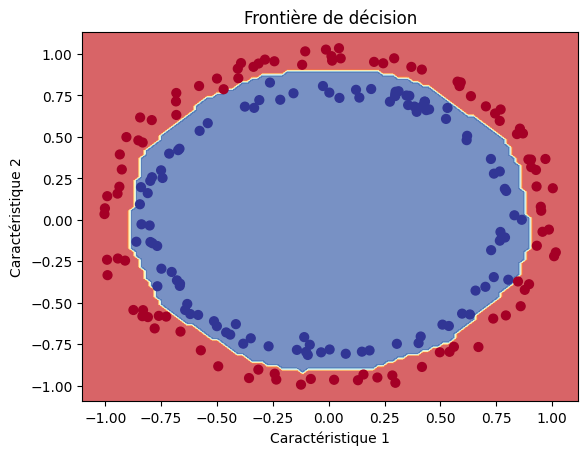

In [16]:
# Visualiser la frontière de décision de model_3 sur l'ensemble d'entraînement.
# Cela montre comment le modèle a appris à séparer les classes sur les données qu'il a vues pendant l'entraînement.
print("Frontière de décision pour le Modèle 3 (entraînement):")
plot_decision_boundary(model_3, X_train, y_train)

# Visualiser la frontière de décision de model_3 sur l'ensemble de test.
# Cela est crucial pour voir si le modèle généralise bien à des données qu'il n'a jamais vues.
# Une bonne performance ici indique une faible sur-apprentissage.
print("Frontière de décision pour le Modèle 3 (test):")
plot_decision_boundary(model_3, X_test, y_test)

## 9. Résumer les points clés

### Résumé des apprentissages clés:

*   **Types de classification:** Nous avons exploré la classification binaire, multi-classe et multi-étiquette, comprenant les scénarios d'application de chacun.
*   **Construction de modèles de réseaux de neurones:** Nous avons appris à construire des modèles séquentiels dans TensorFlow avec des couches denses, en choisissant les fonctions d'activation et les optimiseurs appropriés.
*   **Amélioration du modèle:** L'ajout de couches cachées, de plus de neurones, l'augmentation des époques et l'utilisation d'optimiseurs plus sophistiqués comme Adam ont considérablement amélioré la capacité du modèle à apprendre des relations non linéaires.
*   **Visualisation des frontières de décision:** La fonction `plot_decision_boundary` s'est avérée essentielle pour comprendre visuellement comment le modèle prend des décisions et pour diagnostiquer les performances.
*   **Importance des fonctions d'activation:** Les fonctions d'activation comme ReLU et Sigmoïde sont cruciales pour permettre aux réseaux de neurones de modéliser des relations complexes. ReLU est excellente pour les couches cachées et Sigmoïde pour les sorties de classification binaire.
*   **Séparation entraînement/test:** La division des données en ensembles d'entraînement et de test est fondamentale pour évaluer la capacité de généralisation d'un modèle et éviter le sur-apprentissage.

### Analyse des améliorations:

Le passage d'un modèle de base à une seule couche dense à un modèle plus profond avec des couches cachées et des fonctions d'activation ReLU a transformé la performance. Le premier modèle, linéaire, n'a pas pu résoudre le problème des cercles concentriques. Le modèle amélioré, en revanche, a atteint une précision de 100 % sur les données d'entraînement et de test, démontrant sa capacité à apprendre des frontières de décision non linéaires complexes. Cette amélioration est directement attribuable à:

1.  **Augmentation de la capacité du modèle:** Plus de couches et de neurones permettent au modèle de capturer des motifs plus complexes.
2.  **Fonctions d'activation non linéaires (ReLU):** Elles introduisent la non-linéarité nécessaire pour que le réseau puisse approximer des fonctions complexes.
3.  **Optimiseur Adam:** Un algorithme d'optimisation plus avancé qui ajuste de manière adaptative les taux d'apprentissage pour chaque paramètre, conduisant à une convergence plus rapide et potentiellement meilleure.
4.  **Plus d'époques:** Donner au modèle plus d'opportunités d'apprendre et de s'adapter aux données.

En résumé, la visualisation des données et l'ajustement des hyperparamètres (architecture du modèle, fonctions d'activation, optimiseur, nombre d'époques) sont des étapes critiques dans le développement de modèles de classification performants et généralisables.

## 4. Améliorer le modèle

Nous allons maintenant améliorer le modèle de base en ajoutant plus de couches denses (plus de neurones) et en utilisant l'optimiseur Adam. Nous allons également augmenter le nombre d'époques pour permettre au modèle d'apprendre davantage à partir des données.

Perte du modèle amélioré: 0.0002
Précision du modèle amélioré: 1.0000


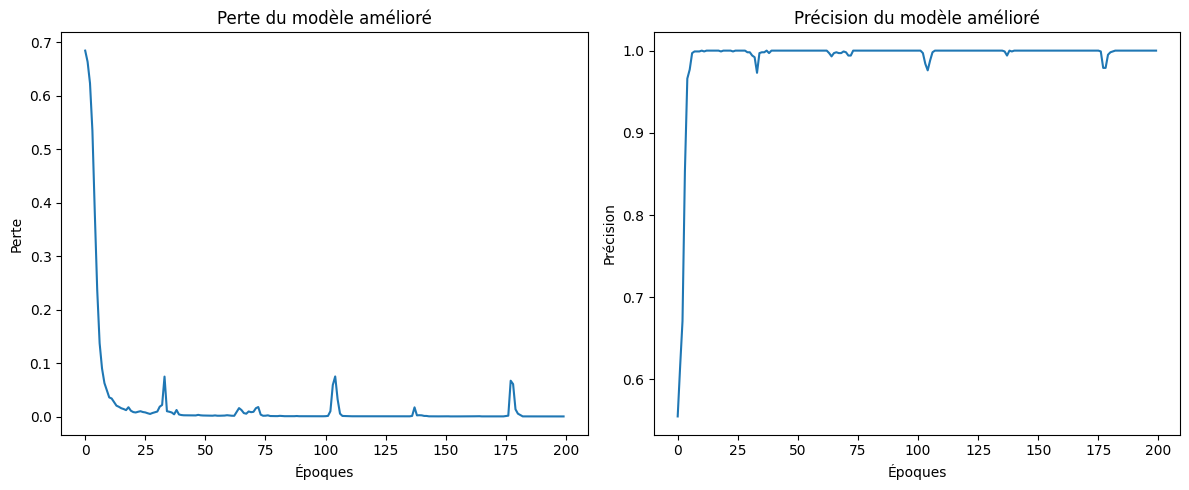

In [13]:
# Créer un modèle de réseau de neurones séquentiel plus complexe.
model_2 = tf.keras.Sequential([
    # Première couche dense cachée avec 10 neurones et fonction d'activation ReLU (Rectified Linear Unit).
    # ReLU aide le modèle à apprendre des relations non linéaires.
    tf.keras.layers.Dense(10, activation='relu'),
    # Deuxième couche dense cachée avec 10 neurones et fonction d'activation ReLU.
    tf.keras.layers.Dense(10, activation='relu'),
    # Couche de sortie avec 1 neurone et fonction d'activation sigmoïde pour la classification binaire.
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compiler le modèle avec l'optimiseur Adam.
model_2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(), # Fonction de perte pour la classification binaire.
    # optimizer=tf.keras.optimizers.Adam(learning_rate=0.01): Utilise l'optimiseur Adam avec un taux d'apprentissage de 0.01.
    # Adam est un optimiseur adaptatif souvent plus performant que SGD pour de nombreux problèmes.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy'] # Mesure la précision.
)

# Entraîner le modèle avec plus d'époques pour permettre un meilleur apprentissage.
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Entraîner sur 200 époques, sans afficher la progression.

# Évaluer le modèle amélioré sur l'ensemble de données complet.
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
# Afficher la perte et la précision.
print(f"Perte du modèle amélioré: {loss_2:.4f}")
print(f"Précision du modèle amélioré: {accuracy_2:.4f}")

# Afficher l'historique de la perte et de la précision pour le modèle amélioré.
plt.figure(figsize=(12, 5))

# Premier sous-graphique: Perte du modèle amélioré.
plt.subplot(1, 2, 1)
plt.plot(history_2.history['loss'])
plt.title('Perte du modèle amélioré')
plt.xlabel('Époques')
plt.ylabel('Perte')

# Deuxième sous-graphique: Précision du modèle amélioré.
plt.subplot(1, 2, 2)
plt.plot(history_2.history['accuracy'])
plt.title('Précision du modèle amélioré')
plt.xlabel('Époques')
plt.ylabel('Précision')

# Ajuster la disposition et afficher les graphiques.
plt.tight_layout()
plt.show()

In [9]:
# Importation des bibliothèques nécessaires pour l'analyse de données et la construction de modèles de réseaux de neurones.
import numpy as np # Pour les opérations numériques et les tableaux.
import pandas as pd # Pour la manipulation et l'analyse de données (non utilisé directement ici, mais bonne pratique).
import matplotlib.pyplot as plt # Pour la création de visualisations et de graphiques.
import tensorflow as tf # La principale bibliothèque pour construire et entraîner des modèles de réseaux de neurones.
from sklearn.datasets import make_circles # Utilisé pour générer un jeu de données synthétique de cercles concentriques.

Ensuite, nous allons créer un jeu de données synthétique en utilisant `make_circles` de scikit-learn. Ce jeu de données est idéal pour tester les classificateurs non linéaires.

In [10]:
# Définir le nombre d'échantillons (points de données) à générer.
samples = 1000

# Générer le jeu de données de cercles concentriques.
# X: Les caractéristiques (coordonnées x et y de chaque point).
# y: Les étiquettes (0 ou 1) indiquant à quel cercle appartient chaque point.
# noise: Ajoute un peu de bruit aux données pour rendre la tâche de classification plus réaliste.
# random_state: Assure la reproductibilité de la génération du jeu de données.
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

# Afficher les 5 premières lignes des caractéristiques (X) pour un aperçu.
print('X : ', X[:5])
print('\n')
# Afficher les 5 premières étiquettes (y) pour un aperçu.
print('y : ', y[:5])

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y :  [1 1 1 1 0]


Maintenant, visualisons le jeu de données pour mieux comprendre sa distribution.

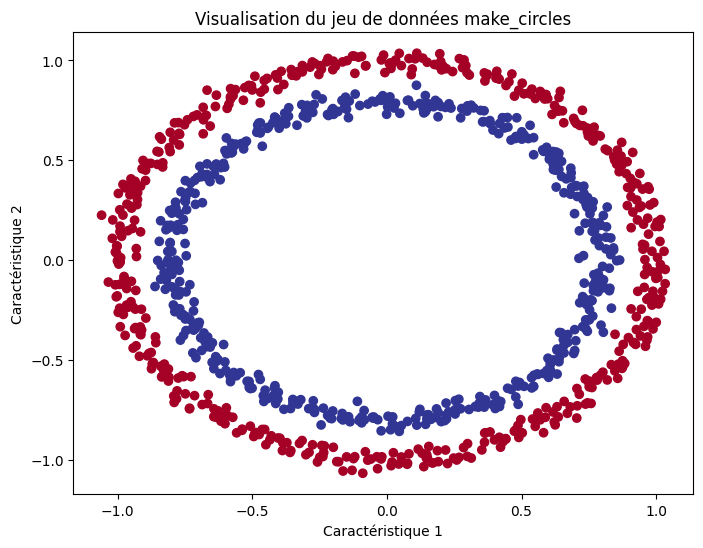

In [11]:
# Créer une nouvelle figure pour le graphique avec une taille spécifique.
plt.figure(figsize=(8, 6))

# Créer un nuage de points où chaque point est coloré selon son étiquette (y).
# X[:, 0]: Toutes les valeurs de la première caractéristique (axe x).
# X[:, 1]: Toutes les valeurs de la deuxième caractéristique (axe y).
# c=y: La couleur de chaque point est déterminée par sa classe (0 ou 1).
# cmap=plt.cm.RdYlBu: Utilise une carte de couleurs rouge-jaune-bleu pour distinguer les classes.
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

# Ajouter un titre au graphique.
plt.title('Visualisation du jeu de données make_circles')

# Ajouter des étiquettes aux axes x et y.
plt.xlabel('Caractéristique 1')
plt.ylabel('Caractéristique 2')

# Afficher le graphique.
plt.show()

## 3. Construire un modèle de réseau de neurones de base

Nous allons créer un modèle séquentiel simple avec une seule couche dense pour commencer. Nous utiliserons la fonction d'activation `sigmoid` pour la couche de sortie, car il s'agit d'un problème de classification binaire, et `binary_crossentropy` comme fonction de perte.

Perte du modèle de base: 0.6933
Précision du modèle de base: 0.5000


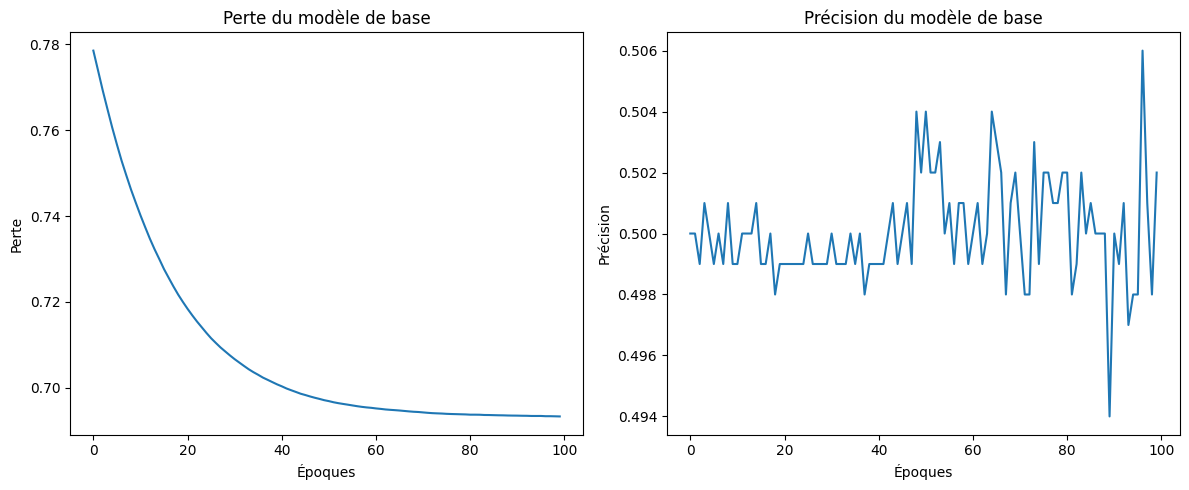

In [12]:
# Créer un modèle de réseau de neurones séquentiel (couche après couche).
model_1 = tf.keras.Sequential([
    # Ajouter une couche dense (Dense) avec 1 neurone.
    # activation='sigmoid': Utilise la fonction d'activation sigmoïde pour la sortie, adaptée à la classification binaire (0 ou 1).
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compiler le modèle: Configurer le processus d'apprentissage.
model_1.compile(
    # loss=tf.keras.losses.BinaryCrossentropy(): Fonction de perte adaptée à la classification binaire.
    loss=tf.keras.losses.BinaryCrossentropy(),
    # optimizer=tf.keras.optimizers.SGD(): Utilise l'optimiseur Descente de Gradient Stochastique.
    optimizer=tf.keras.optimizers.SGD(),
    # metrics=['accuracy']: Mesure la précision du modèle pendant l'entraînement et l'évaluation.
    metrics=['accuracy']
)

# Entraîner le modèle.
# X, y: Les données d'entraînement (caractéristiques et étiquettes).
# epochs=100: Le modèle parcourt les données 100 fois.
# verbose=0: Supprime l'affichage de la progression de l'entraînement pour chaque époque.
history_1 = model_1.fit(X, y, epochs=100, verbose=0)

# Évaluer le modèle sur le jeu de données complet.
# verbose=0: Supprime l'affichage du processus d'évaluation.
loss_1, accuracy_1 = model_1.evaluate(X, y, verbose=0)
# Afficher la perte et la précision obtenues.
print(f"Perte du modèle de base: {loss_1:.4f}")
print(f"Précision du modèle de base: {accuracy_1:.4f}")

# Afficher l'historique de la perte et de la précision au cours des époques.
plt.figure(figsize=(12, 5))

# Premier sous-graphique: Perte du modèle.
plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, premier graphique.
plt.plot(history_1.history['loss']) # Tracer la perte enregistrée à chaque époque.
plt.title('Perte du modèle de base')
plt.xlabel('Époques')
plt.ylabel('Perte')

# Deuxième sous-graphique: Précision du modèle.
plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, deuxième graphique.
plt.plot(history_1.history['accuracy']) # Tracer la précision enregistrée à chaque époque.
plt.title('Précision du modèle de base')
plt.xlabel('Époques')
plt.ylabel('Précision')

# Ajuster automatiquement les paramètres du graphique pour éviter le chevauchement.
plt.tight_layout()
# Afficher les graphiques.
plt.show()